# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

The intuition behind adding a penalty to mean squared error is to control how complex the model becomes. If we only minimize MSE, the model will try to fit the training data as closely as possible, which can lead to very large coefficients and overfitting. By adding a penalty that increases with the size of the coefficients, we are essentially discouraging the model from relying too heavily on any single feature. This encourages simpler models that generalize better to new data, rather than models that memorize noise in the training set.

2. How does regularization provide a way of exploring the bias-variance trade-off?

Regularization directly helps us explore the bias-variance trade-off by adjusting how flexible the model is. When the penalty term is small or zero, the model can fit the data very closely, which leads to low bias but high variance since it may overfit. As the penalty increases, the model becomes simpler because the coefficients are shrunk toward zero, which increases bias but reduces variance. By tuning the strength of the penalty, we can find a balance where the model is not too complex but still captures the important patterns in the data.

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

The main difference between LASSO and Ridge regression lies in how they penalize the coefficients. Ridge regression uses a squared penalty (L2), which shrinks coefficients toward zero but does not eliminate them completely. This means all variables remain in the model, just with smaller influence. In contrast, LASSO uses an absolute value penalty (L1), which can shrink some coefficients exactly to zero, effectively performing feature selection. Because of this, Ridge is typically better when most variables contribute a little to the outcome, while LASSO is useful when only a subset of variables are truly important.

4. How do we typically scale variables for use in regularized regression? Why?

In regularized regression, we typically standardize the variables so that each feature has a mean of zero and a standard deviation of one. This is important because the penalty term depends on the size of the coefficients, and without scaling, variables with larger units or ranges would dominate the penalty unfairly. Standardizing ensures that all features are treated equally, allowing the regularization method to shrink coefficients based on their importance rather than their scale.

5. How is the penalty $\alpha$ typically selected?

The penalty parameter, α, is typically chosen using cross-validation. The idea is to try a range of α values, train the model on part of the data, and then test how well it performs on a validation set. The value that gives the lowest validation error is selected. This approach works well because it focuses on how the model will perform on new data, rather than just how well it fits the training set.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

When doing cross-validation, we usually don't include the penalty term when calculating the MSE. The goal at that stage is just to see how well the model predicts outcomes on unseen data. The penalty is important during training because it helps control complexity, but it's not something we actually care about when evaluating prediction accuracy. So for comparison, we stick to regular MSE.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [2]:
! git clone https://github.com/Humzah-Syed/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 30 (delta 8), reused 4 (delta 4), pack-reused 18 (from 1)
Receiving objects: 100% (30/30), 31.69 KiB | 10.56 MiB/s, done.
Resolving deltas: 100% (9/9), done.
Download complete
Extracting data files...
Data extracted


In [4]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

df = pd.read_csv('./data/cars_hw.csv', encoding="utf-8")

In [5]:
df["Age"] = 2024 - df["Make_Year"]

# select features
X = df[["Mileage_Run", "Age"]]
y = df["Price"]  # adjust if needed

# polynomial features (degree 3)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])

# standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [6]:
lr = LinearRegression()
lr.fit(X_scaled, y)

coeffs = pd.Series(lr.coef_, index=feature_names)
print(coeffs)

Mileage_Run          6.686165e+05
Age                 -1.841941e+05
Mileage_Run^2       -1.494679e+05
Mileage_Run Age     -1.251592e+06
Age^2                2.156399e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    2.833392e+05
Mileage_Run Age^2    5.280829e+05
Age^3               -1.389370e+05
dtype: float64


The interaction between Mileage_Run and Age is negative, indicating that as both variables increase together, the price decreases more sharply. This reflects a compounding depreciation effect for older cars with higher mileage.

In [7]:
alphas = np.logspace(1, 3, 20)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso.fit(X_scaled, y)

print("Best alpha:", lasso.alpha_)

Best alpha: 483.2930238571752


Using 20-fold cross-validation, the optimal penalty parameter was selected as around 483.29. This is a relatively large value, which suggests that a good amount of regularization is needed for this model. In other words, the unregularized polynomial regression is likely overfitting, and the LASSO model improves performance by shrinking the coefficients more aggressively.

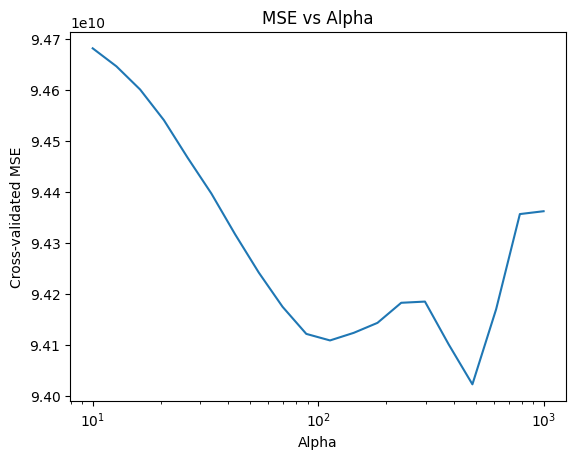

In [8]:
mse_mean = np.mean(lasso.mse_path_, axis=1)

plt.plot(lasso.alphas_, mse_mean)
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Cross-validated MSE")
plt.title("MSE vs Alpha")
plt.show()

The plot of cross-validated MSE against α shows a clear pattern where the error decreases at first and then starts increasing again. For very small α values, the model is too flexible and overfits the data, leading to higher validation error. As α increases, the model becomes more stable and the error decreases. However, after a certain point (around 483), the model becomes too simple and starts underfitting, which causes the error to rise again. This reflects the bias-variance trade-off pretty clearly.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 618295679975.2812, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 182143840738.40625, tolerance: 12469725702.912619
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 200000353812.89062, tolerance: 12471993172.815535
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWar

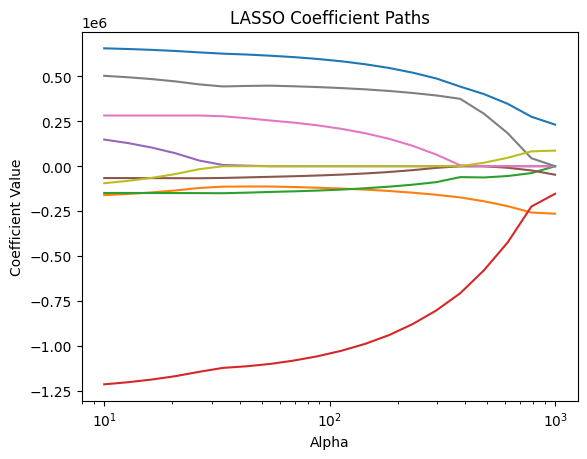

In [9]:
coefs = []

for a in alphas:
    l = LassoCV(alphas=[a], cv=20, max_iter=10000)
    l.fit(X_scaled, y)
    coefs.append(l.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")
plt.title("LASSO Coefficient Paths")
plt.show()

In [10]:
lasso_coeffs = pd.Series(lasso.coef_, index=feature_names)

selected = lasso_coeffs[lasso_coeffs != 0]
zeroed = lasso_coeffs[lasso_coeffs == 0]

print("Selected features:\n", selected)
print("Proportion zero:", len(zeroed) / len(lasso_coeffs))

Selected features:
 Mileage_Run          401025.259657
Age                 -194803.116695
Mileage_Run^2        -62539.290093
Mileage_Run Age     -578788.661090
Mileage_Run Age^2    292015.025679
Age^3                 19133.908573
dtype: float64
Proportion zero: 0.3333333333333333


LASSO selects a subset of features by shrinking some coefficients exactly to zero. In this case, 6 out of 9 polynomial features are retained, while 3 are set to zero. This means that about 33.3% of the coefficients are eliminated. The features that remain include Mileage_Run, Age, their interaction, and a few higher-order terms, which suggests that these variables carry the most predictive power. Overall, LASSO simplifies the model by removing less important polynomial terms while still keeping the key relationships.

In [11]:
comparison = pd.DataFrame({
    "Linear": lr.coef_,
    "LASSO": lasso.coef_
}, index=feature_names)

print(comparison)

                         Linear          LASSO
Mileage_Run        6.686165e+05  401025.259657
Age               -1.841941e+05 -194803.116695
Mileage_Run^2     -1.494679e+05  -62539.290093
Mileage_Run Age   -1.251592e+06 -578788.661090
Age^2              2.156399e+05      -0.000000
Mileage_Run^3     -6.514490e+04      -0.000000
Mileage_Run^2 Age  2.833392e+05       0.000000
Mileage_Run Age^2  5.280829e+05  292015.025679
Age^3             -1.389370e+05   19133.908573


Comparing the standard linear regression to the LASSO model, most coefficients decrease in magnitude under LASSO due to the regularization penalty. For example, the interaction term between Mileage_Run and Age is still negative but is significantly reduced in size compared to the original linear model. Some coefficients, such as Mileage_Run^2 and Age^3, also shrink noticeably.

However, not all coefficients shrink. For instance, the coefficient for Mileage_Run actually decreases slightly, but some higher-order interaction terms like Mileage_Run Age^2 remain relatively large, indicating they still play an important role in the model. Additionally, several features are set exactly to zero under LASSO, which does not happen in standard linear regression and highlights LASSO's ability to perform feature selection.

Overall, the LASSO model produces a simpler and more stable set of coefficients. While most coefficients shrink, the key relationships—especially involving mileage, age, and their interaction—are still preserved, just in a more controlled way.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [15]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
import matplotlib.pyplot as plt

# load data
df = pd.read_csv("./data/heart_failure_clinical_records_dataset.csv", encoding="utf-8")

# continuous variables
cont = df[["age", "ejection_fraction", "serum_creatinine"]]

# polynomial (degree 3)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(cont)
poly_names = poly.get_feature_names_out(cont.columns)

# scale
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

# categorical (binary) variables
cat = df[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]

# interactions only
poly_cat = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_cat = poly_cat.fit_transform(cat)
cat_names = poly_cat.get_feature_names_out(cat.columns)

# combine
X = np.hstack([X_poly_scaled, X_cat])
feature_names = list(poly_names) + list(cat_names)

# target
y = df["DEATH_EVENT"]

In [16]:
lr = LinearRegression()
lr.fit(X, y)

coeffs = pd.Series(lr.coef_, index=feature_names)
print(coeffs.sort_values())

age^2                                    -3.678654
serum_creatinine^2                       -2.647041
ejection_fraction                        -2.192494
age ejection_fraction serum_creatinine   -1.577665
ejection_fraction^2 serum_creatinine     -1.270043
ejection_fraction^3                      -1.250341
serum_creatinine                         -0.853588
age^2 serum_creatinine                   -0.697522
age ejection_fraction                    -0.600918
smoking                                  -0.102687
age ejection_fraction^2                  -0.081206
diabetes                                 -0.070705
anaemia high_blood_pressure              -0.027251
high_blood_pressure                      -0.007934
anaemia                                   0.008093
anaemia diabetes                          0.026159
anaemia smoking                           0.064908
serum_creatinine^3                        0.072156
high_blood_pressure smoking               0.101455
diabetes high_blood_pressure   

When running the linear regression, some of the coefficient signs appear counterintuitive at first. For example, age has a positive coefficient, suggesting that higher age increases the likelihood of death, which makes sense. However, other related terms like age^2 have a negative coefficient, which seems contradictory. Similarly, ejection_fraction has a negative coefficient, but higher-order terms like ejection_fraction^2 are positive.

This apparent contradiction comes from the fact that the model includes higher-order polynomial terms and interactions. The effect of a variable is not captured by a single coefficient anymore, but instead by a combination of terms. For example, the overall impact of age depends on age, age^2, and age^3 together, not just one of them individually. These higher-order terms allow the model to capture nonlinear relationships, which can explain why individual coefficients may seem inconsistent on their own. When taken together, they can still represent a reasonable overall pattern in the data.

In [18]:
alphas = np.logspace(-5, 5, 30)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso.fit(X, y)

print("Best alpha:", lasso.alpha_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.1655699255817744, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.019422437013997, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7.954870463666694, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Conv

Best alpha: 0.005736152510448681


Using 20-fold cross-validation, the optimal penalty parameter was selected a around 0.0057. This is a relatively small value, which suggests that only a light amount of regularization is needed for this model. Unlike the previous case, the model here does not require heavy shrinking of coefficients, which may indicate that the feature set is not overfitting as aggressively or that the signal in the data is stronger.

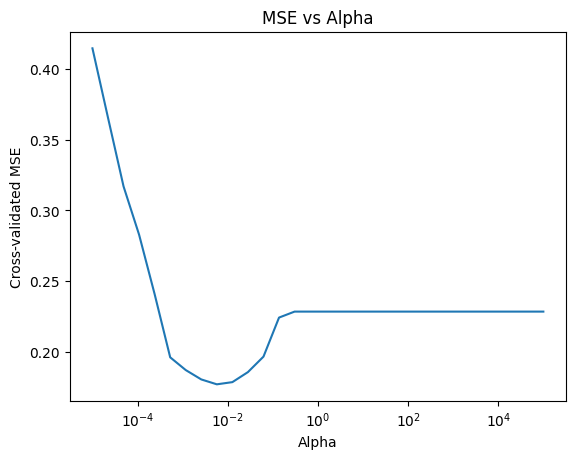

In [19]:
mse_mean = np.mean(lasso.mse_path_, axis=1)

plt.plot(lasso.alphas_, mse_mean)
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Cross-validated MSE")
plt.title("MSE vs Alpha")
plt.show()

The plot of cross-validated MSE against α shows a clear U-shaped pattern. For very small values of α (around 10^-5), the MSE is relatively high, which suggests the model is overfitting due to being too flexible. As α increases, the MSE decreases and reaches its minimum around 10^-2, which aligns closely with the selected optimal value of α ≈ 0.0057.

After this point, as α continues to increase, the MSE begins to rise again and eventually levels off. This indicates that the model is becoming too constrained and is starting to underfit the data. Overall, the graph reflects the bias-variance trade-off, where small α leads to high variance, large α leads to high bias, and the optimal α balances the two to minimize prediction error.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 17.267280475605553, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 16.845445710400853, tolerance: 0.005874295774647887
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 17.044417767715373, tolerance: 0.005915492957746482
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Co

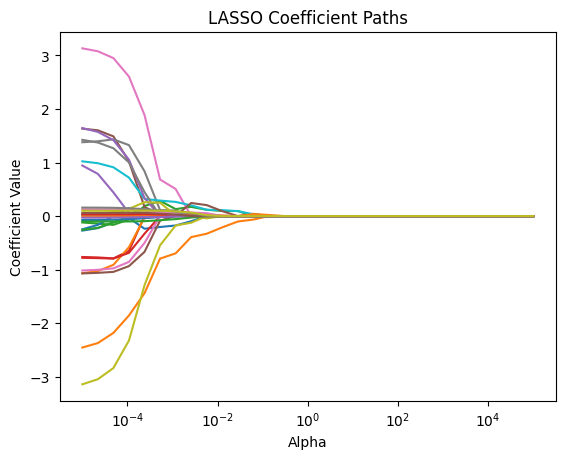

In [20]:
coefs = []

for a in alphas:
    l = LassoCV(alphas=[a], cv=20, max_iter=10000)
    l.fit(X, y)
    coefs.append(l.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")
plt.title("LASSO Coefficient Paths")
plt.show()

In [21]:
lasso_coeffs = pd.Series(lasso.coef_, index=feature_names)

selected = lasso_coeffs[lasso_coeffs != 0]
zeroed = lasso_coeffs[lasso_coeffs == 0]

print("Selected features:\n", selected)
print("Proportion zero:", len(zeroed) / len(lasso_coeffs))

# compare
comparison = pd.DataFrame({
    "Linear": lr.coef_,
    "LASSO": lasso.coef_
}, index=feature_names)

print(comparison)

Selected features:
 ejection_fraction                      -0.329656
serum_creatinine                        0.116875
age^3                                   0.117992
ejection_fraction^3                     0.204822
ejection_fraction^2 serum_creatinine    0.032801
serum_creatinine^3                     -0.043266
anaemia                                 0.014178
diabetes                                0.000607
high_blood_pressure                     0.013608
diabetes high_blood_pressure            0.053968
diabetes smoking                        0.003466
high_blood_pressure smoking             0.017805
dtype: float64
Proportion zero: 0.5862068965517241
                                          Linear     LASSO
age                                     1.539156 -0.000000
ejection_fraction                      -2.192494 -0.329656
serum_creatinine                       -0.853588  0.116875
age^2                                  -3.678654  0.000000
age ejection_fraction                  -0.6009

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

The ridge regression objective function is:

$$
\frac{1}{n} \sum_{i=1}^n (y_i^* - b_0 - b_1 x_i^*)^2 + \alpha b_1^2
$$


Because the data is mean-centered, we have:

$$
b_0 = 0
$$

The solution for the slope coefficient is:

$$
b_1 = \frac{\sum x_i^* y_i^*}{\sum (x_i^*)^2 + \alpha}
$$

As $\alpha$ increases, the denominator becomes larger, so $b_1$ decreases.
This means the slope shrinks toward zero and the regression line becomes flatter.

With LASSO, the penalty is $\alpha |b_1|$, which is not differentiable at $0$.
Because of this, we cannot solve it using standard derivatives and instead consider cases.

The optimal solution is:

If the relationship between $x$ and $y$ is strong, then $b_1 \neq 0$
If the relationship is weak, then $b_1 = 0$

So LASSO sets $b_1 = 0$ when the correlation between $x$ and $y$ is small relative to $\alpha$, which is why it performs feature selection.